# Small Image Classification Using Convolutional Neural Network (CNN)

In [2]:
import tensorflow as tf

In [3]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [4]:
import numpy as np

### Load the dataset

In [5]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [6]:
(X_train, y_train), (X_test,y_test)= datasets.cifar10.load_data()

In [7]:
X_train.shape

(50000, 32, 32, 3)

In [9]:
X_test.shape

(10000, 32, 32, 3)

In [10]:
y_train.shape

(50000, 1)

In [11]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [12]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [13]:
y_test=y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [14]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [15]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

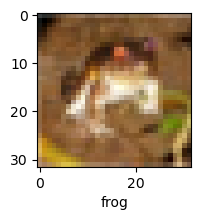

In [16]:
plot_sample(X_train,y_train,0)

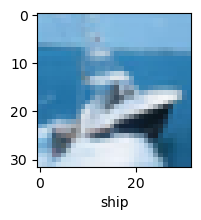

In [17]:
plot_sample(X_train,y_train,8)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

### Normalizing the training data

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Build simple artificial neural network for image classification

In [19]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

C:\Users\guggi\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.3513 - loss: 1.8161
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.4274 - loss: 1.6255
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.4564 - loss: 1.5397
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.4778 - loss: 1.4811
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.4962 - loss: 1.4315


In [20]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.63      0.47      0.54      1000
           1       0.64      0.58      0.61      1000
           2       0.38      0.34      0.36      1000
           3       0.30      0.51      0.38      1000
           4       0.58      0.18      0.28      1000
           5       0.55      0.17      0.26      1000
           6       0.41      0.73      0.52      1000
           7       0.52      0.60      0.56      1000
           8       0.56      0.69      0.62      1000
           9       0.58      0.54      0.56      1000

    accuracy                           0.48     10000
   macro avg       0.51      0.48      0.47     10000
weighted avg       0.51      0.48      0.47     10000



### Build a convolutional neural network to train our images

In [21]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\guggi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [27]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8033 - loss: 0.5603
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8109 - loss: 0.5314
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8243 - loss: 0.4948
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8334 - loss: 0.4688
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8441 - loss: 0.4386
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8536 - loss: 0.4133
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8601 - loss: 0.3882
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.8717 - loss: 0.3594
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8772 - loss: 0.3397
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8843 - loss: 0.3209


In [26]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6935 - loss: 0.9553


[0.9553143382072449, 0.6934999823570251]

In [25]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[1.91072433e-03, 1.47283263e-05, 1.16717545e-02, 6.39227152e-01,
        2.00645044e-03, 1.09526686e-01, 5.61604043e-03, 1.76055974e-03,
        2.28262797e-01, 3.13350665e-06],
       [5.07212989e-02, 6.84089437e-02, 2.94890451e-05, 6.32274464e-08,
        2.81537865e-07, 3.96094402e-09, 4.51717312e-07, 6.88691371e-09,
        8.80739033e-01, 1.00298283e-04],
       [2.96957850e-01, 4.17389482e-01, 1.23069407e-02, 3.04638827e-03,
        1.43318507e-03, 2.11371039e-03, 8.10828060e-04, 3.43220425e-04,
        2.60784149e-01, 4.81419079e-03],
       [9.39992189e-01, 3.36902076e-03, 3.95518076e-03, 3.76705313e-04,
        7.66342180e-03, 1.03871907e-05, 3.35336481e-05, 3.07513663e-04,
        4.42373455e-02, 5.46227857e-05],
       [1.21974308e-05, 7.45460711e-05, 6.13292819e-03, 1.33123212e-02,
        5.53874850e-01, 1.43708603e-03, 4.24802244e-01, 1.32045810e-04,
        2.05473523e-04, 1.63052555e-05]], dtype=float32)

In [28]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(1), np.int64(0), np.int64(4)]

In [29]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

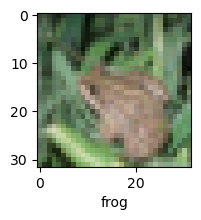

In [40]:
plot_sample(X_test,y_test,4)

In [41]:
classes[y_classes[4]]

'deer'

In [35]:
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [43]:
print("Classification Report: \n", classification_report(y_test, y_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.69      0.76      0.72      1000
           1       0.80      0.84      0.82      1000
           2       0.61      0.58      0.59      1000
           3       0.59      0.41      0.49      1000
           4       0.61      0.67      0.64      1000
           5       0.61      0.60      0.60      1000
           6       0.76      0.75      0.75      1000
           7       0.64      0.81      0.72      1000
           8       0.78      0.83      0.81      1000
           9       0.87      0.68      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000

